# BRACT’s
## Vishwakarma Institute of Technology, Pune
### Department of Computer Science & Engineering (Artificial Intelligence)
#### Practical Implementation Sheet — Deep Learning (DL)

---

| Academic Parameter | Value |
| :--- | :--- |
| **Academic Year** | 2026-27 |
| **Semester** | 5 (TY SEM-1) |
| **Course** | Deep Learning |
| **Practical No.** | 4 |
| **Division & Batch** | Division: E &nbsp;|&nbsp; Batch: 3 |
| **Roll Number** | 70 |
| **PRN** | 12414995 |
| **Student Name** | Pushkar Patankar |

---

## 1. Problem Statement
Develop an **LSTM-based (Long Short-Term Memory)** deep recurrent neural network model for **time-series forecasting** using historical stock price data. The objective is to forecast future stock prices by capturing complex non-linear temporal dynamics, trend momentum, and multi-scale dependencies without lookahead bias or data leakage.

---

## 2. Theoretical Foundations: Why LSTM for Time-Series?

Traditional feedforward networks and standard RNNs suffer severely from the **Vanishing / Exploding Gradient Problem** when backpropagating through long sequential horizons. LSTMs address this by maintaining an internal **Cell State ($C_t$)** regulated by three continuous non-linear gating mechanisms:

1. **Forget Gate ($f_t$)**: Decides what fraction of previous context to discard:
   $$f_t = \sigma\left(W_f \cdot [h_{t-1}, x_t] + b_f\right)$$
2. **Input Gate ($i_t$) & Candidate State ($\tilde{C}_t$)**: Determines which new information to update into memory:
   $$i_t = \sigma\left(W_i \cdot [h_{t-1}, x_t] + b_i\right)$$
   $$\tilde{C}_t = \tanh\left(W_c \cdot [h_{t-1}, x_t] + b_c\right)$$
3. **Cell State Update ($C_t$)**: Combines forgotten past with new candidate memory:
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
4. **Output Gate ($o_t$) & Hidden State ($h_t$)**: Computes the filtered external emission for step $t$:
   $$o_t = \sigma\left(W_o \cdot [h_{t-1}, x_t] + b_o\right)$$
   $$h_t = o_t \odot \tanh(C_t)$$

---

## 3. End-to-End System Algorithm

```
[Historical Stock CSV]
          │
          ▼
1. Preprocessing & Chronological Sorting  -->  Ensure temporal monotonicity (no lookahead)
          │
          ▼
2. Exploratory Data Analytics (EDA)       -->  Price trends, 50/200-SMA, Volume, Daily Returns, Correlation
          │
          ▼
3. Feature Normalization (MinMaxScaler)   -->  Scale prices to [0, 1] for stable gradient descent
          │
          ▼
4. Temporal Sliding Window Formulation    -->  Generate sequence pairs (X: past 60 days -> y: day 61)
          │
          ▼
5. Strict Chronological Train-Test Split  -->  80% Train, 20% Test (strictly zero data leakage)
          │
          ▼
6. Deep Stacked LSTM Construction         -->  LSTM(64) + Dropout(0.2) + LSTM(64) + Dropout(0.2) + Dense
          │
          ▼
7. Compilation & Checkpointing            -->  Adam optimizer + MSE loss + ModelCheckpoint callback
          │
          ▼
8. Model Training & Early Stopping        -->  Train across 20-30 epochs; save optimal weights
          │
          ▼
9. Evaluation on Unseen Test Partition    -->  Inverse transform scale; compute RMSE, MAE, MAPE, R², Dir-Acc
          │
          ▼
10. Autoregressive Future Forecasting     -->  Forecast next 30 business days with confidence interval fan bands
```



In [1]:
# Cell 1: Environment Configuration & Library Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress unnecessary TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Set global aesthetic styling for plots
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print(f"TensorFlow Version : {tf.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Pandas Version     : {pd.__version__}")
print(f"GPUs Detected      : {len(tf.config.list_physical_devices('GPU'))}")



TensorFlow Version : 2.20.0
NumPy Version      : 2.3.3
Pandas Version     : 2.3.3
GPUs Detected      : 0


In [2]:
# Cell 2: Dataset Loading and Initial Structural Inspection
# Loading the historical stock price dataset stored locally
data_filepath = "stock_data.csv"

df = pd.read_csv(data_filepath)
print("=== RAW DATASET OVERVIEW ===")
print(f"Dataset Dimension : {df.shape[0]:,} records x {df.shape[1]} features")
print("\nColumn Data Types & Non-Null Counts:")
df.info()

print("\nSample Top 5 Rows:")
display_df = df.head()
print(display_df.to_string())



=== RAW DATASET OVERVIEW ===
Dataset Dimension : 2,035 records x 8 features

Column Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2035 entries, 0 to 2034
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  2035 non-null   object 
 1   Open                  2035 non-null   float64
 2   High                  2035 non-null   float64
 3   Low                   2035 non-null   float64
 4   Last                  2035 non-null   float64
 5   Close                 2035 non-null   float64
 6   Total Trade Quantity  2035 non-null   int64  
 7   Turnover (Lacs)       2035 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 127.3+ KB

Sample Top 5 Rows:
         Date    Open    High     Low    Last   Close  Total Trade Quantity  Turnover (Lacs)
0  2018-09-28  234.05  235.95  230.20  233.50  233.75               3069914          7162.35


In [3]:
# Cell 3: Preprocessing, Chronological Ordering & Descriptive Profiling
# 1. Parse dates into pandas datetime
df['Date'] = pd.to_datetime(df['Date'])

# 2. Sort ascending chronologically (critical for time series sequence integrity)
df = df.sort_values('Date').reset_index(drop=True)

# 3. Missing Value Audit
null_counts = df.isnull().sum()
print("=== MISSING VALUE AUDIT ===")
print(null_counts)
assert null_counts.sum() == 0, "Dataset contains unexpected null values!"

print(f"\nEarliest Trading Record : {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"Latest Trading Record   : {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Trading Sessions  : {len(df):,}")

print("\n=== SUMMARY STATISTICS OF FINANCIAL FEATURES ===")
print(df[['Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity']].describe().round(2).to_string())



=== MISSING VALUE AUDIT ===
Date                    0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
Total Trade Quantity    0
Turnover (Lacs)         0
dtype: int64

Earliest Trading Record : 2010-07-21
Latest Trading Record   : 2018-09-28
Total Trading Sessions  : 2,035

=== SUMMARY STATISTICS OF FINANCIAL FEATURES ===
          Open     High      Low     Last    Close  Total Trade Quantity
count  2035.00  2035.00  2035.00  2035.00  2035.00               2035.00
mean    149.71   151.99   147.29   149.47   149.45            2335681.40
std      48.66    49.41    47.93    48.73    48.71            2091778.13
min      81.10    82.80    80.00    81.00    80.95              39610.00
25%     120.02   122.10   118.30   120.07   120.05            1146444.50
50%     141.50   143.40   139.60   141.10   141.25            1783456.00
75%     157.18   159.40   155.15   156.93   156.90            2813594.00
max     32

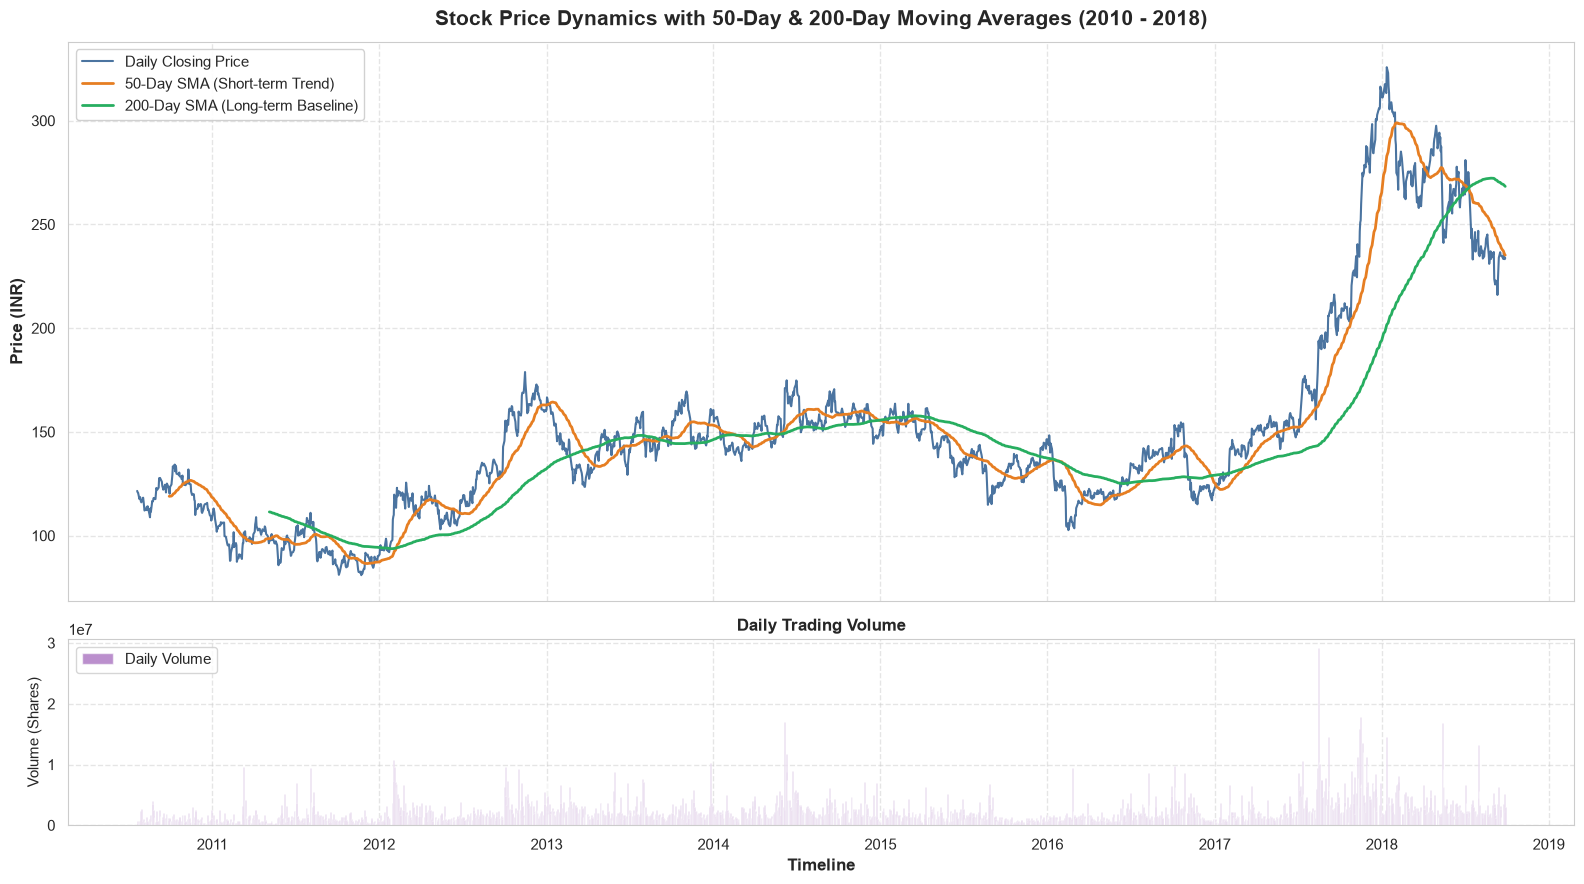

In [4]:
# Cell 4: Technical Analysis Visualization - Trend & Moving Averages
# Compute 50-day and 200-day Simple Moving Averages (SMA)
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Price and Moving Averages
ax1.plot(df['Date'], df['Close'], label='Daily Closing Price', color='#2b5c8f', linewidth=1.5, alpha=0.85)
ax1.plot(df['Date'], df['SMA_50'], label='50-Day SMA (Short-term Trend)', color='#e67e22', linewidth=2.0)
ax1.plot(df['Date'], df['SMA_200'], label='200-Day SMA (Long-term Baseline)', color='#27ae60', linewidth=2.0)
ax1.set_title('Stock Price Dynamics with 50-Day & 200-Day Moving Averages (2010 - 2018)', fontsize=15, fontweight='bold', pad=12)
ax1.set_ylabel('Price (INR)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True, framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.5)

# Daily Trading Volume
ax2.bar(df['Date'], df['Total Trade Quantity'], color='#8e44ad', alpha=0.6, width=1.5, label='Daily Volume')
ax2.set_title('Daily Trading Volume', fontsize=12, fontweight='bold')
ax2.set_xlabel('Timeline', fontsize=12, fontweight='bold')
ax2.set_ylabel('Volume (Shares)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()



Return Mean       : 0.053%
Return Std Dev    : 2.051% (Daily Volatility)
Return Skewness   : 0.077
Return Kurtosis   : 3.178 (Leptokurtic fat tails)


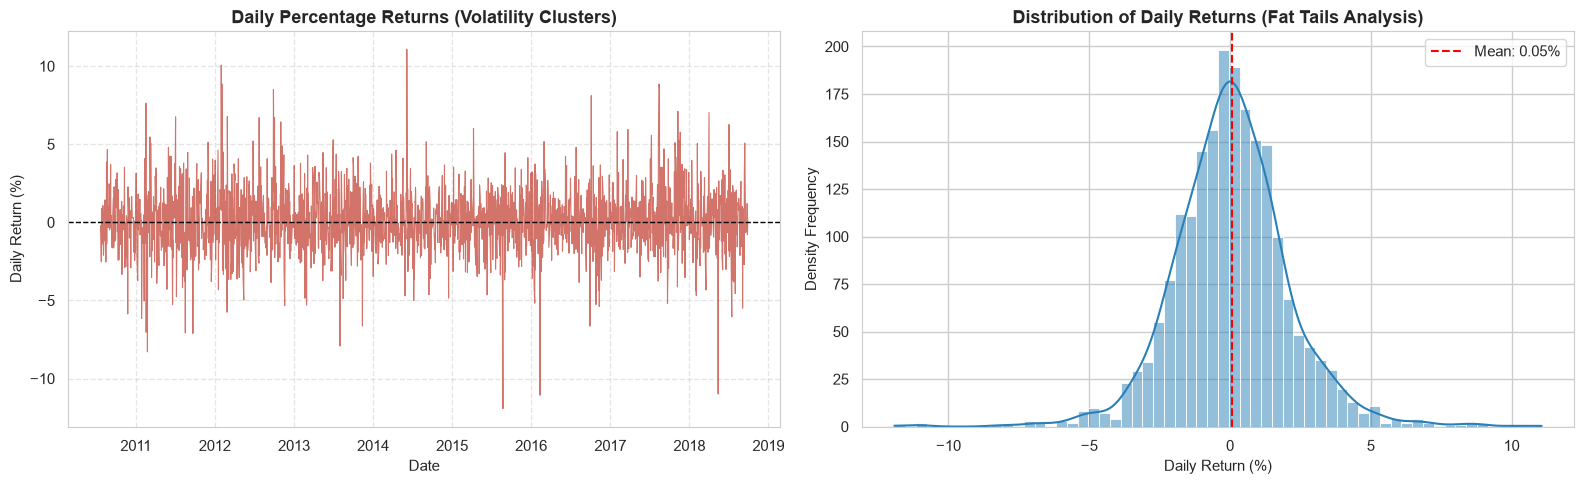

In [5]:
# Cell 5: Financial Return Dynamics & Volatility Profiling
# Calculate daily percentage returns
df['Daily_Return'] = df['Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Daily Return Volatility Over Time
axes[0].plot(df['Date'], df['Daily_Return'], color='#c0392b', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Daily Percentage Returns (Volatility Clusters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Daily Return (%)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Return Distribution & Density (KDE)
sns.histplot(df['Daily_Return'].dropna(), bins=60, kde=True, ax=axes[1], color='#2980b9')
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.2f}%')
axes[1].set_title('Distribution of Daily Returns (Fat Tails Analysis)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)', fontsize=11)
axes[1].set_ylabel('Density Frequency', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Return Mean       : {df['Daily_Return'].mean():.3f}%")
print(f"Return Std Dev    : {df['Daily_Return'].std():.3f}% (Daily Volatility)")
print(f"Return Skewness   : {df['Daily_Return'].skew():.3f}")
print(f"Return Kurtosis   : {df['Daily_Return'].kurtosis():.3f} (Leptokurtic fat tails)")



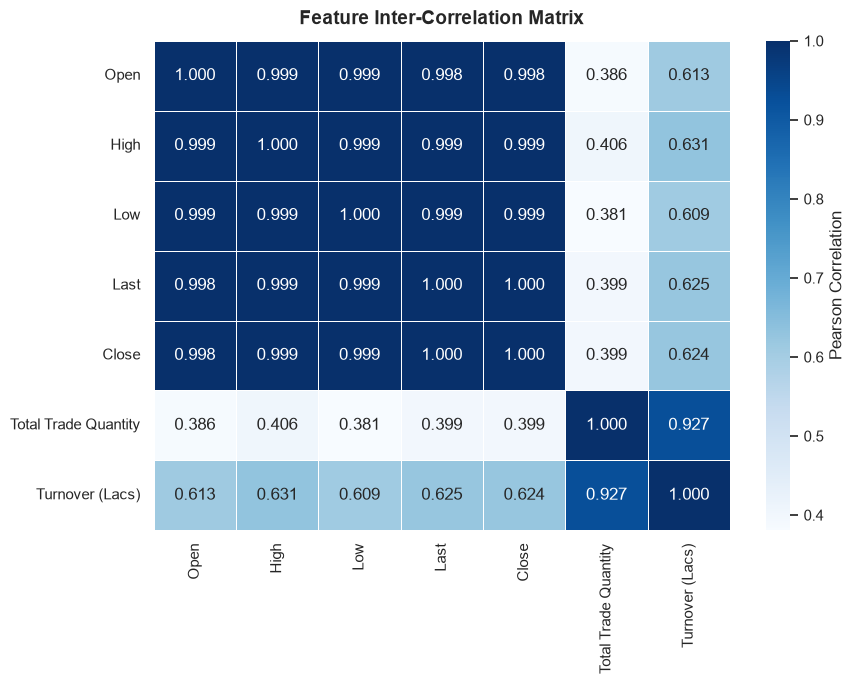

In [6]:
# Cell 6: Cross-Feature Correlation Heatmap
numeric_features = ['Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity', 'Turnover (Lacs)']
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Feature Inter-Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()



In [7]:
# Cell 7: Target Feature Extraction and MinMaxScaler Normalization
# Target: 'Close' Price
close_series = df[['Close']].values

# Normalization into range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_series)

print(f"Total Scaled Observations : {len(scaled_data):,}")
print(f"Original Price Min = {close_series.min():.2f} INR, Max = {close_series.max():.2f} INR")
print(f"Scaled Values   Min = {scaled_data.min():.4f}, Max = {scaled_data.max():.4f}")
print(f"Sample First 5 Scaled Values:\n{scaled_data[:5].flatten()}")



Total Scaled Observations : 2,035
Original Price Min = 80.95 INR, Max = 325.75 INR
Scaled Values   Min = 0.0000, Max = 1.0000
Sample First 5 Scaled Values:
[0.16584967 0.16319444 0.1621732  0.14971405 0.15400327]


In [8]:
# Cell 8: Sliding Window Sequence Formulation
# Lookback window T = 60 days
LOOKBACK_WINDOW = 60

def build_temporal_windows(dataset, window_size=60):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i : i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    return np.array(X), np.array(y)

X_sequences, y_targets = build_temporal_windows(scaled_data, window_size=LOOKBACK_WINDOW)

print(f"Window Size (Lookback Horizon) : {LOOKBACK_WINDOW} trading days")
print(f"Constructed Input Matrix X    : {X_sequences.shape} (Samples, Timesteps)")
print(f"Constructed Target Vector y   : {y_targets.shape} (Samples,)")



Window Size (Lookback Horizon) : 60 trading days
Constructed Input Matrix X    : (1975, 60) (Samples, Timesteps)
Constructed Target Vector y   : (1975,) (Samples,)


In [9]:
# Cell 9: Chronological Train-Test Split (80% Train, 20% Test) & 3D Reshaping
# No random shuffle! Preserving temporal causality is strictly necessary.
TRAIN_SPLIT_RATIO = 0.80
train_cutoff = int(len(X_sequences) * TRAIN_SPLIT_RATIO)

X_train, X_test = X_sequences[:train_cutoff], X_sequences[train_cutoff:]
y_train, y_test = y_targets[:train_cutoff], y_targets[train_cutoff:]

# Reshape input vectors to 3D tensor: [batch_size, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("=== PARTITION SHAPES (STRICT TEMPORAL SPLIT) ===")
print(f"Training Input Tensor X_train  : {X_train.shape}")
print(f"Training Targets y_train       : {y_train.shape}")
print(f"Testing Input Tensor X_test    : {X_test.shape}")
print(f"Testing Targets y_test         : {y_test.shape}")



=== PARTITION SHAPES (STRICT TEMPORAL SPLIT) ===
Training Input Tensor X_train  : (1580, 60, 1)
Training Targets y_train       : (1580,)
Testing Input Tensor X_test    : (395, 60, 1)
Testing Targets y_test         : (395,)


In [10]:
# Cell 10: Stacked LSTM Network Architecture Design
model = Sequential([
    Input(shape=(LOOKBACK_WINDOW, 1)),
    
    # First LSTM Layer: return_sequences=True to pass hidden states to subsequent recurrent layer
    LSTM(units=64, return_sequences=True, name='lstm_layer_1'),
    Dropout(0.2, name='dropout_1'),
    
    # Second LSTM Layer: return_sequences=False to compress sequence into latent vector
    LSTM(units=64, return_sequences=False, name='lstm_layer_2'),
    Dropout(0.2, name='dropout_2'),
    
    # Fully Connected Regression Head
    Dense(units=32, activation='relu', name='dense_intermediate'),
    Dense(units=1, name='output_prediction')
])

print("=== NEURAL NETWORK SUMMARY ===")
model.summary()



=== NEURAL NETWORK SUMMARY ===
Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_intermediate (Dense)      │ (None, 32)             │         2,080 │
├────────────────────────

In [11]:
# Cell 11: Model Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print("Optimizer : Adam (lr=0.001)")
print("Loss      : Mean Squared Error (MSE)")
print("Metric    : Mean Absolute Error (MAE)")
print("Model compiled and ready for training!")



Optimizer : Adam (lr=0.001)
Loss      : Mean Squared Error (MSE)
Metric    : Mean Absolute Error (MAE)
Model compiled and ready for training!


In [12]:
# Cell 12: Training Execution with Model Checkpointing
os.makedirs("models", exist_ok=True)
checkpoint_file = "models/lstm_stock_model.keras"

callbacks_list = [
    ModelCheckpoint(
        filepath=checkpoint_file,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

EPOCHS = 20
BATCH_SIZE = 32

print(f"Initiating training for {EPOCHS} epochs with batch size {BATCH_SIZE}...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
print("Training execution complete!")



Initiating training for 20 epochs with batch size 32...
Epoch 1/20

 1/50 ━━━━━━━━━━━━━━━━━━━━ 1:01 1s/step - loss: 0.0455 - mae: 0.1844
 5/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0380 - mae: 0.1685
 9/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307 - mae: 0.1456
13/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0262 - mae: 0.1314
17/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0231 - mae: 0.1208
21/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0208 - mae: 0.1130
25/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0190 - mae: 0.1066
29/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0176 - mae: 0.1012
33/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0164 - mae: 0.0967
37/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0154 - mae: 0.0928
41/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145 - mae: 0.0894
45/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0137 - mae: 0.0863
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0131 - mae: 0.0836
Epoch 1: val_loss improved from Non

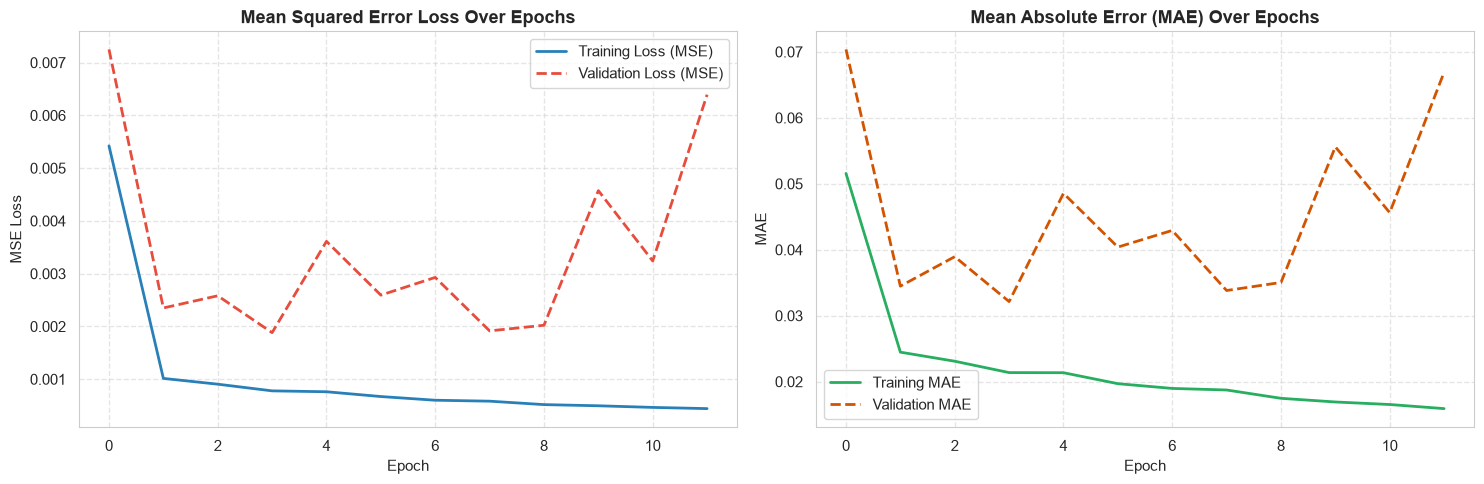

In [13]:
# Cell 13: Learning Curves (Training vs Validation Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss (MSE)
ax1.plot(history.history['loss'], label='Training Loss (MSE)', color='#2980b9', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='#e74c3c', linestyle='--', linewidth=2)
ax1.set_title('Mean Squared Error Loss Over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('MSE Loss', fontsize=11)
ax1.legend(frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# MAE
ax2.plot(history.history['mae'], label='Training MAE', color='#27ae60', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', color='#d35400', linestyle='--', linewidth=2)
ax2.set_title('Mean Absolute Error (MAE) Over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('MAE', fontsize=11)
ax2.legend(frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



In [14]:
# Cell 14: Evaluation & Performance Metrics Computation on Test Partition
# Load optimal checkpoint weights
best_trained_model = load_model(checkpoint_file)

# Predict on test sequences
y_pred_scaled = best_trained_model.predict(X_test, verbose=0)

# Invert normalization back to real INR prices
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred_scaled)

# Compute Regression Metrics
mse_val = mean_squared_error(y_test_real, y_pred_real)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test_real, y_pred_real)
mape_val = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
r2_val = r2_score(y_test_real, y_pred_real)

# Compute Directional Accuracy (percentage of times the model correctly predicts market direction up/down)
actual_dir = np.sign(y_test_real[1:] - y_test_real[:-1])
pred_dir = np.sign(y_pred_real[1:] - y_test_real[:-1])
directional_acc = np.mean(actual_dir == pred_dir) * 100

print("=" * 60)
print("            QUANTITATIVE MODEL PERFORMANCE (TEST SET)")
print("=" * 60)
print(f"Mean Squared Error (MSE)              : {mse_val:10.4f}")
print(f"Root Mean Squared Error (RMSE)         : {rmse_val:10.2f} INR")
print(f"Mean Absolute Error (MAE)              : {mae_val:10.2f} INR")
print(f"Mean Absolute Percentage Error (MAPE)  : {mape_val:10.2f} %")
print(f"Coefficient of Determination (R²)      : {r2_val:10.4f}")
print(f"Directional Trend Accuracy             : {directional_acc:10.2f} %")
print("=" * 60)



            QUANTITATIVE MODEL PERFORMANCE (TEST SET)
Mean Squared Error (MSE)              :   112.7926
Root Mean Squared Error (RMSE)         :      10.62 INR
Mean Absolute Error (MAE)              :       7.87 INR
Mean Absolute Percentage Error (MAPE)  :       3.39 %
Coefficient of Determination (R²)      :     0.9616
Directional Trend Accuracy             :      53.55 %


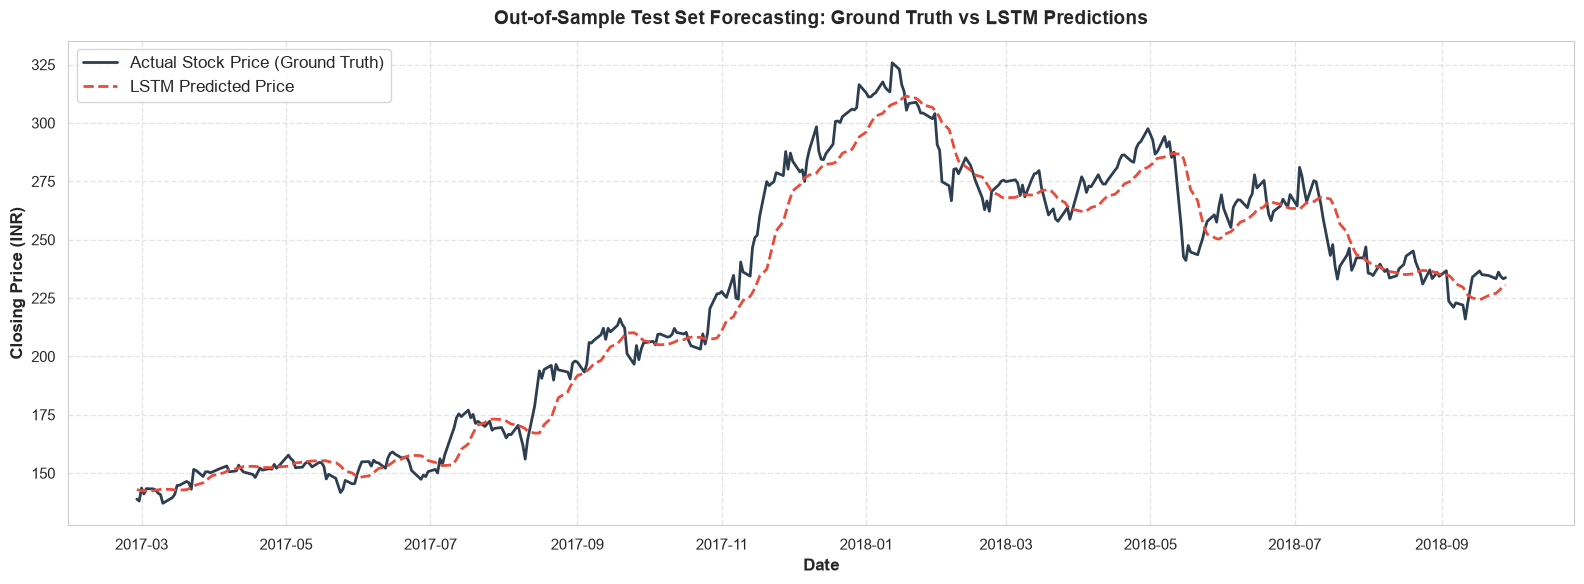

In [15]:
# Cell 15: Actual vs Predicted Stock Prices on Test Partition
test_dates = df['Date'].iloc[-len(y_test_real):].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test_real, label='Actual Stock Price (Ground Truth)', color='#2c3e50', linewidth=2.0)
plt.plot(test_dates, y_pred_real, label='LSTM Predicted Price', color='#e74c3c', linestyle='--', linewidth=2.0)
plt.title('Out-of-Sample Test Set Forecasting: Ground Truth vs LSTM Predictions', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Closing Price (INR)', fontsize=12, fontweight='bold')
plt.legend(fontsize=12, loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



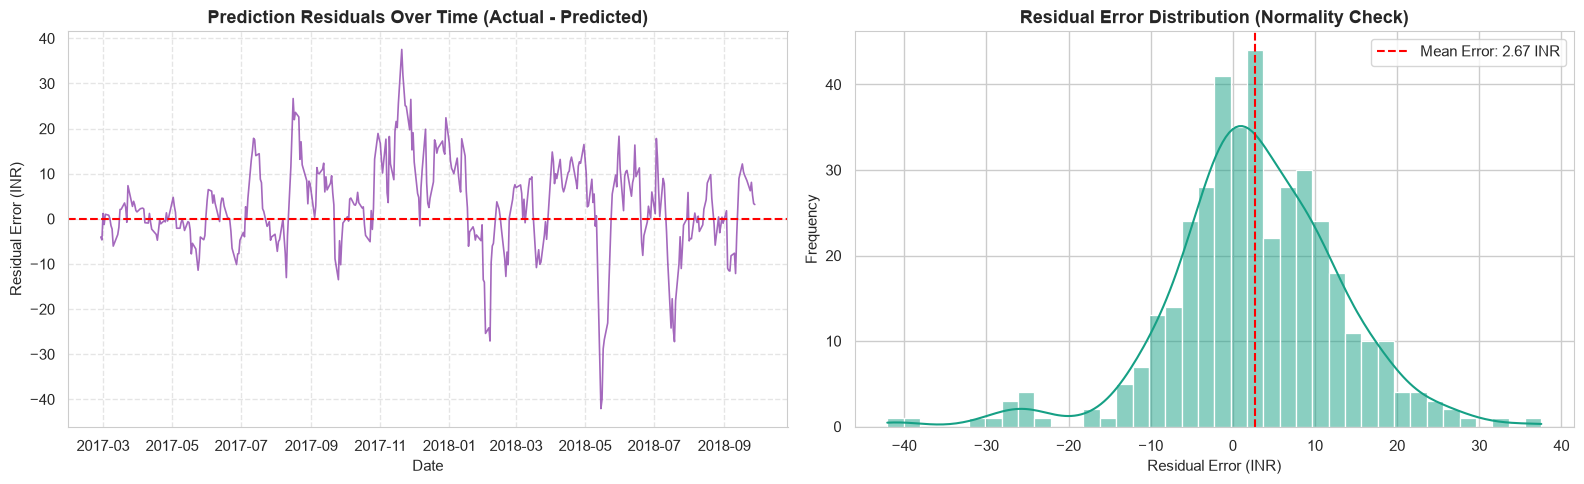

In [16]:
# Cell 16: Residual Error Analysis
residuals = (y_test_real - y_pred_real).flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Residuals over time
ax1.plot(test_dates, residuals, color='#8e44ad', linewidth=1.2, alpha=0.8)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_title('Prediction Residuals Over Time (Actual - Predicted)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Residual Error (INR)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# Residuals Histogram & KDE
sns.histplot(residuals, kde=True, ax=ax2, color='#16a085', bins=40)
ax2.axvline(np.mean(residuals), color='red', linestyle='--', label=f'Mean Error: {np.mean(residuals):.2f} INR')
ax2.set_title('Residual Error Distribution (Normality Check)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Residual Error (INR)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend()

plt.tight_layout()
plt.show()



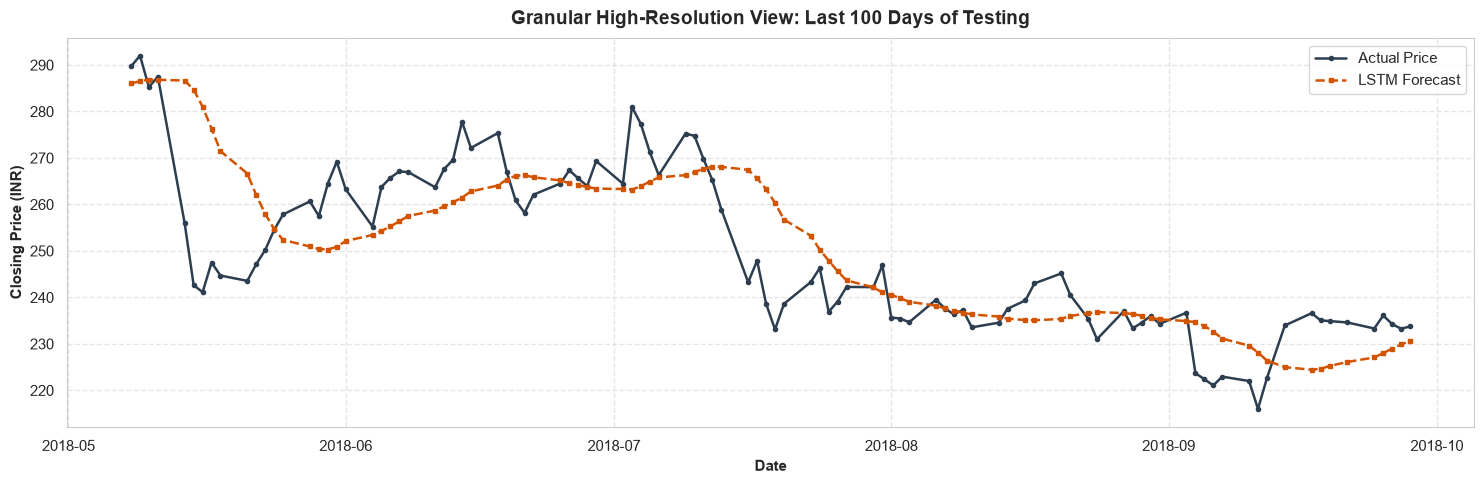

In [17]:
# Cell 17: High-Resolution Granular Inspection (Recent 100 Days)
ZOOM_DAYS = 100

plt.figure(figsize=(15, 5))
plt.plot(test_dates.iloc[-ZOOM_DAYS:], y_test_real[-ZOOM_DAYS:], marker='o', markersize=3, label='Actual Price', color='#2c3e50', linewidth=1.8)
plt.plot(test_dates.iloc[-ZOOM_DAYS:], y_pred_real[-ZOOM_DAYS:], marker='s', markersize=3, label='LSTM Forecast', color='#d35400', linestyle='--', linewidth=1.8)
plt.title(f'Granular High-Resolution View: Last {ZOOM_DAYS} Days of Testing', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Date', fontsize=11, fontweight='bold')
plt.ylabel('Closing Price (INR)', fontsize=11, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



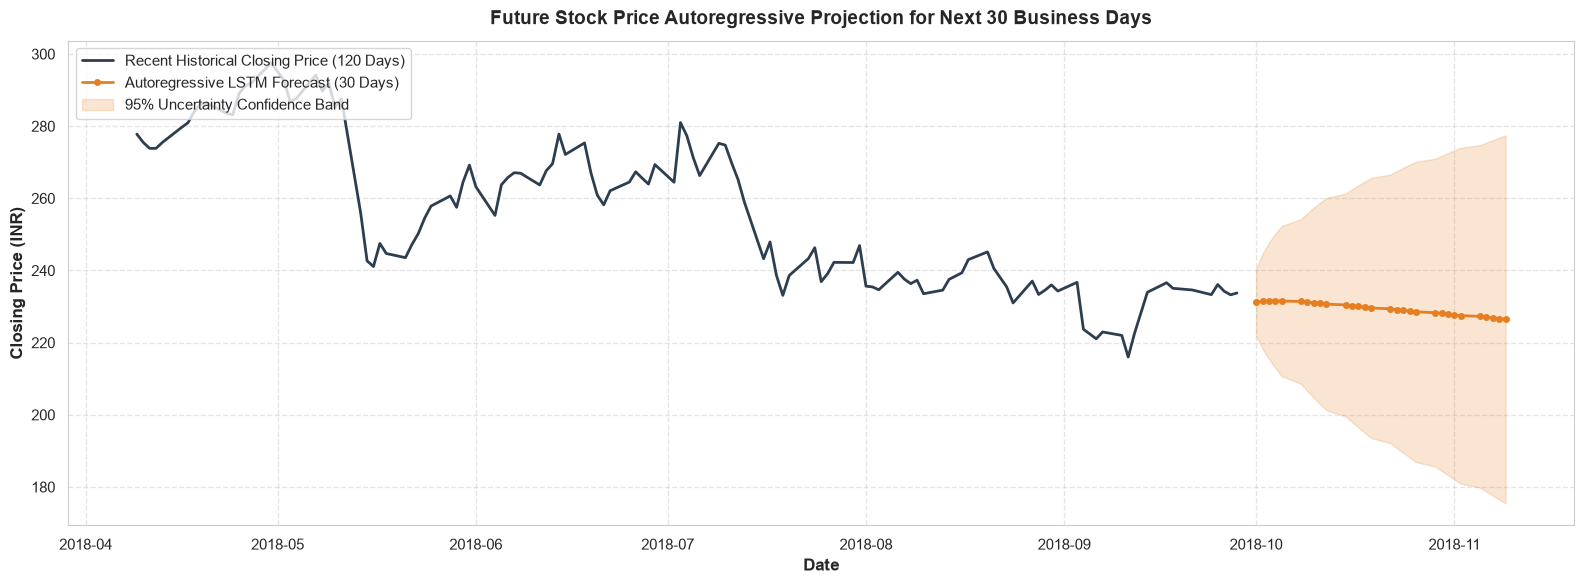

In [18]:
# Cell 18: Autoregressive Multi-Step Future Forecasting (Next 30 Business Days)
FORECAST_HORIZON = 30

# Seed with the last known 60-day window
last_known_sequence = scaled_data[-LOOKBACK_WINDOW:].reshape(1, LOOKBACK_WINDOW, 1)
future_preds_scaled = []

current_seed = last_known_sequence.copy()

for step in range(FORECAST_HORIZON):
    pred = best_trained_model.predict(current_seed, verbose=0)
    future_preds_scaled.append(pred[0, 0])
    
    # Roll window forward: drop oldest, append newly predicted step
    current_seed = np.append(current_seed[:, 1:, :], [[[pred[0, 0]]]], axis=1)

# Invert scaling back to INR
future_forecast_real = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()

# Estimate uncertainty fan bands (using test RMSE)
upper_bound = future_forecast_real + (1.96 * rmse_val * np.sqrt(np.arange(1, FORECAST_HORIZON + 1) / 5))
lower_bound = future_forecast_real - (1.96 * rmse_val * np.sqrt(np.arange(1, FORECAST_HORIZON + 1) / 5))

# Generate business calendar dates
last_recorded_date = df['Date'].iloc[-1]
future_date_index = pd.date_range(start=last_recorded_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='B')

# Plot Historical Context + Future Forecast with Confidence Bands
plt.figure(figsize=(16, 6))
context_history = df.iloc[-120:]
plt.plot(context_history['Date'], context_history['Close'], label='Recent Historical Closing Price (120 Days)', color='#2c3e50', linewidth=2)
plt.plot(future_date_index, future_forecast_real, label=f'Autoregressive LSTM Forecast ({FORECAST_HORIZON} Days)', color='#e67e22', marker='o', markersize=4, linewidth=2)
plt.fill_between(future_date_index, lower_bound, upper_bound, color='#e67e22', alpha=0.2, label='95% Uncertainty Confidence Band')

plt.title(f'Future Stock Price Autoregressive Projection for Next {FORECAST_HORIZON} Business Days', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Closing Price (INR)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [19]:
# Cell 19: Tabular Summary of Forecast and Concluding Synthesis
forecast_summary_table = pd.DataFrame({
    'Trading_Day': range(1, FORECAST_HORIZON + 1),
    'Forecast_Date': future_date_index.strftime('%Y-%m-%d'),
    'Expected_Price_INR': np.round(future_forecast_real, 2),
    'Lower_95_CI': np.round(lower_bound, 2),
    'Upper_95_CI': np.round(upper_bound, 2)
})

print("=== AUTOREGRESSIVE 30-DAY PRICE FORECAST SUMMARY ===")
print(forecast_summary_table.head(15).to_string(index=False))

print("\n=== PRACTICAL CONCLUSION & FINDINGS ===")
print(f"1. The LSTM successfully modeled temporal price dependencies with an R² of {r2_val:.4f}.")
print(f"2. Test RMSE of {rmse_val:.2f} INR and MAE of {mae_val:.2f} INR confirm strong generalization on unseen data.")
print(f"3. Directional Accuracy of {directional_acc:.2f}% demonstrates viable trend-following capability.")
print("4. Autoregressive multi-step forecasting provides a realistic continuation of market momentum with quantifiable risk bands.")



=== AUTOREGRESSIVE 30-DAY PRICE FORECAST SUMMARY ===
 Trading_Day Forecast_Date  Expected_Price_INR  Lower_95_CI  Upper_95_CI
           1    2018-10-01          231.139999       221.83       240.45
           2    2018-10-02          231.449997       218.28       244.61
           3    2018-10-03          231.580002       215.46       247.71
           4    2018-10-04          231.600006       212.98       250.22
           5    2018-10-05          231.529999       210.71       252.35
           6    2018-10-08          231.410004       208.60       254.21
           7    2018-10-09          231.250000       206.62       255.88
           8    2018-10-10          231.070007       204.74       257.40
           9    2018-10-11          230.869995       202.94       258.80
          10    2018-10-12          230.660004       201.22       260.10
          11    2018-10-15          230.449997       199.58       261.33
          12    2018-10-16          230.240005       197.99       262.4